In [1]:
# RF model for disturbed vs undisturbed binary classification
# aviana
# May 2024
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from imblearn.pipeline import make_pipeline
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import accuracy_score, precision_recall_curve, precision_recall_fscore_support, f1_score, precision_score, recall_score, roc_auc_score, roc_curve, auc
#from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from joblib import dump
import numpy as np
import matplotlib.pyplot as plt
from imblearn.under_sampling import RandomUnderSampler

In [2]:
'''Tried different options:
    1.  24 predictors: All bands and indices in t0 (12 columns) and t-1 (12 columns) (i.e. absolute values of a target year and diffs with previous year)
    2.  14 predictors: SW1, SW2 and indices in t0 (8 columns) + diffs indices (6 columns)
    2b. 14 predictors: SW1_diffs, SW2_diffs and indices in t0 (8 columns) + diffs indices (6 columns)
    3.  12 predictors: indices t0 (6 columns) and indices t-1 (6 columns)'''
# With option 2b I got: F1-score 0.99 for class "0" (undisturbed) and F1-score 0.76 for class "1" (disturbed)

### Data preparation
df = pd.read_csv('/home/ubuntu/work/saved_data/landsat_disturbance_detection/clean_1D_U_Net/deep_disturbance/Data/Training/forest_dataset_timesync_alltiles_landsatbands_indices3_classes_ed5_calibration.csv', sep=';')
print("Original dataframe", df.columns)  

# create disturbance labels
df['class'] = df['class_level1'].apply(lambda x: 1 if x == 'disturbance' else 0)
print(df.head(10))
     
# Remove rows containing NaN values
df = df.dropna()


## filter doubtful samples
df = df[~((df['class_level1'] == 'treed') & (df['NBR'] < 0.5))]
df = df[~((df['class_level1'] == 'treed') & (df['NDVI'] < 0.5))]
df = df[~((df['class_level1'] == 'non-treed') & (df['NBR'] < 0.5))]
df = df[~((df['class_level1'] == 'non-treed') & (df['NDVI'] < 0.5))]
df = df[~((['class_level1'] == 'disturbance') & (df['NBR'] > 0.5))]
df = df[~((['class_level1'] == 'disturbance') & (df['NDVI'] > 0.5))]

# Count the number of samples per class
class_counts = df['class_level1'].value_counts()
print(class_counts)



# When using option 3 from the meny: i.e. only indices
# Define the list of column names to delete
columns_to_delete = ['BLU', 'GRN', 'RED', 'NIR',
                     'BLU_diff', 'GRN_diff', 'RED_diff', 'NIR_diff']  # Add more column names as needed

# Delete columns with specified names
df = df.drop(columns=columns_to_delete, errors='ignore')
print("df modified", df.head())

# label treed and non treed to --> 0 undisturbed and disturbance to 1
class_count = df['class'].value_counts()
print("number of samples per class:", class_count) 

# Define the indices we want to compute differences for
indices_to_diff = ['NBR', 'NDVI', 'TCB', 'TCG', 'TCW', 'DIn']

# Sort dataframe by location and year to ensure proper chronological order
df_sorted = df.sort_values(['country', 'plotid', 'year']).reset_index(drop=True)

# Create a copy to work with
df_with_diffs = df_sorted.copy()

# Initialize difference columns
for index in indices_to_diff:
    df_with_diffs[f'{index}_diff'] = np.nan

# Group by location (country + plotid) and compute differences
for (country, plotid), group in df_sorted.groupby(['country', 'plotid']):
    if len(group) > 1:  # Need at least 2 years to compute differences
        # Sort by year within each group
        group_sorted = group.sort_values('year')
        indices = group_sorted.index
        
        # Compute year-to-year differences for each index
        for i, index in enumerate(indices_to_diff):
            values = group_sorted[index].values
            # Compute differences: current_year - previous_year
            diffs = np.diff(values)
            
            # Assign differences to the later years (skip first year as it has no previous year)
            if len(diffs) > 0:
                df_with_diffs.loc[indices[1:], f'{index}_diff'] = diffs

print('________________________')
print(df_with_diffs.columns)

'''class2= []
for row in df['class_level1']:
    if row == 'disturbance':
        class2.append(1)
    elif row == 'treed': 
        class2.append(0)
df['class2'] = class2'''

# Split the data into predictors (X) and response (y)
y = df_with_diffs['class'] 
X = df_with_diffs.drop(['numerical_id','fid', 'class'	, 'uniqueid', 'country', 'plotid', 'year', 'class_level1', 'class_level2', 'merged_id', 'x', 'y', 'Tile_ID', 'merged_id', 'new_class2_v5' ], axis=1) # otherwise, select all columns except the last one  data.iloc[:, :-1]       #df['class2'] 
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)



Original dataframe Index(['fid', 'country', 'plotid', 'year', 'class_level1', 'class_level2',
       'new_class2_v5', 'uniqueid', 'numerical_id', 'x', 'y', 'Tile_ID',
       'merged_id', 'BLU', 'GRN', 'RED', 'NIR', 'SW1', 'SW2', 'NBR', 'NDVI',
       'TCB', 'TCG', 'TCW', 'DIn'],
      dtype='object')
   fid  country  plotid  year class_level1 class_level2  new_class2_v5  \
0    0  albania       1  1985        treed        treed              0   
1    1  albania       1  1986        treed        treed              0   
2    2  albania       1  1987        treed        treed              0   
3    3  albania       1  1988        treed        treed              0   
4    4  albania       1  1989        treed        treed              0   
5    5  albania       1  1990        treed        treed              0   
6    6  albania       1  1991        treed        treed              0   
7    7  albania       1  1992        treed        treed              0   
8    8  albania       1  1993   

Training Accuracy: 0.9507300447588711
Testing Accuracy: 0.9409103663502536
**************
overall accuracy 94.09103663502536
f1 score classification: 0.21906657018813314
Threshold: 0.1 | F1-score: 0.046 | Precision: 0.024 | Recall: 0.891 | ROC-AUC: 0.798
Threshold: 0.2 | F1-score: 0.065 | Precision: 0.034 | Recall: 0.765 | ROC-AUC: 0.798
Threshold: 0.3 | F1-score: 0.094 | Precision: 0.051 | Recall: 0.653 | ROC-AUC: 0.798
Threshold: 0.4 | F1-score: 0.150 | Precision: 0.086 | Recall: 0.566 | ROC-AUC: 0.798
Threshold: 0.5 | F1-score: 0.219 | Precision: 0.141 | Recall: 0.492 | ROC-AUC: 0.798
Threshold: 0.6 | F1-score: 0.300 | Precision: 0.229 | Recall: 0.433 | ROC-AUC: 0.798
Threshold: 0.7 | F1-score: 0.381 | Precision: 0.374 | Recall: 0.388 | ROC-AUC: 0.798
Threshold: 0.8 | F1-score: 0.437 | Precision: 0.546 | Recall: 0.365 | ROC-AUC: 0.798
Threshold: 0.9 | F1-score: 0.469 | Precision: 0.745 | Recall: 0.342 | ROC-AUC: 0.798
**************
Best hyperparameters: {'randomforestclassifier__n_

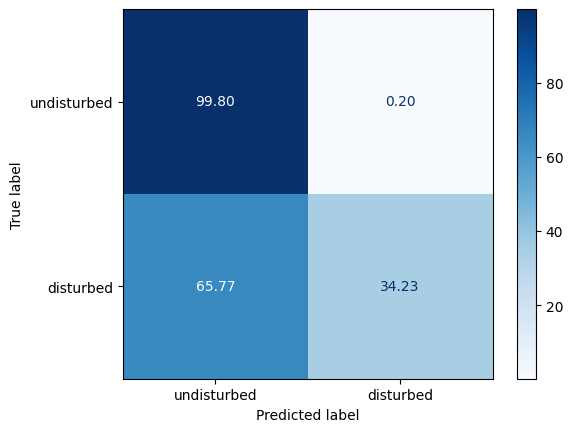

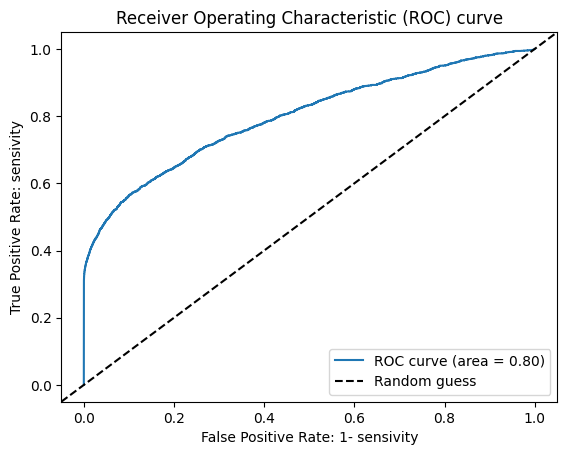

In [3]:
### 2) Model preparation
# compute class weights
class_weight_dict = {0: 0.5, 1: 70}   # to balance
# Define the parameter grid to search over
param_grid = {
    'n_estimators': np.arange(50, 150, 10),
    'max_depth': [5, 10, 15],
    'min_samples_split': np.arange(2, 10, 2),
    'min_samples_leaf': np.arange(1, 10, 2),
    'max_features': ['sqrt', 'log2', None], 
    'bootstrap': [True, False], 
    'class_weight': ['balanced', 'balanced_subsample', class_weight_dict] 
} 

# Train the random forest classifier with RandomizedSearchCV and oversample the minority
clf = RandomForestClassifier(n_jobs=5) 
# Create an instance of the RandomOverSampler
oversampler = RandomOverSampler()
# Create a pipeline with the oversampler and random forest classifier
pipeline = make_pipeline(oversampler, clf)

# Define the parameter distributions for the random search
param_distributions = {
    'randomforestclassifier__n_estimators': param_grid['n_estimators'],
    'randomforestclassifier__max_depth': param_grid['max_depth'],
    'randomforestclassifier__min_samples_split': param_grid['min_samples_split'],
    'randomforestclassifier__min_samples_leaf': param_grid['min_samples_leaf'],
    'randomforestclassifier__max_features': param_grid['max_features'],
    'randomforestclassifier__bootstrap': param_grid['bootstrap'],
    'randomforestclassifier__class_weight': param_grid['class_weight']
}

random_search = RandomizedSearchCV(pipeline, param_distributions, n_jobs=5, scoring='f1') #, n_jobs=-1, verbose=1, error_score='raise') 
random_search.fit(X_train, y_train)

# Get the best parameters found by Random Search
best_params = random_search.best_estimator_.get_params()
# Filter out unexpected parameters
best_params = {k: v for k, v in best_params.items() if k in random_search.get_params()}
# Create a new Random Forest model with the best parameters
best_rf = RandomForestClassifier(**best_params)
# Train the model
best_rf.fit(X_train, y_train)

# Evaluate on the training data
y_train_pred = random_search.predict(X_train)
train_accuracy = accuracy_score(y_train, y_train_pred)
print("Training Accuracy:", train_accuracy)
# Evaluate on the testing data
y_test_pred = random_search.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)
print("Testing Accuracy:", test_accuracy)
  
# Predict on the test data - to fine tunning probablities if useful
proba = random_search.predict_proba(X_test) #_test)#[:, 1]
# predict
y_pred = random_search.predict(X_test)  
# set a custom threshold
#threshold = 0.4
# classify the samples using the custom threshold if needed (by default RF uses 0.5 threshold)
#y_pred = np.where(proba[:, 1] >= threshold, 1, 0)      


### 3) Evaluate the model's performance on the test sample
acc = accuracy_score(y_test, y_pred) 
print('**************')
print("overall accuracy", acc * 100)
# per class evaluation
test_f1 = f1_score(y_test, y_pred) 
print ('f1 score classification:', test_f1)  

# Define a range of thresholds to try and test performances when variating the probab.
thresholds = np.arange(0.1, 1.0, 0.1)
# Evaluate the performance of the classifier for each threshold
for threshold in thresholds:
    y_pred = (proba[:,1] >= threshold).astype(int)
    f1 = f1_score(y_test, y_pred)  #y_test
    precision = precision_score(y_test, y_pred)  # y_test
    recall = recall_score(y_test, y_pred)  # y_test
    roc_auc = roc_auc_score(y_test, proba[:,1])  # y_test
    print(f"Threshold: {threshold:.1f} | F1-score: {f1:.3f} | Precision: {precision:.3f} | Recall: {recall:.3f} | ROC-AUC: {roc_auc:.3f}")

print('**************')
print("Best hyperparameters:", random_search.best_params_)
print('**************')
print("Best OOB score:", random_search.best_score_)
print('**************')
print("best estimator", random_search.best_estimator_)
print('**************')
    
# Get the best estimator from the random search
best_estimator = random_search.best_estimator_
# Get the feature importances of the best estimator
feature_importances = best_estimator.named_steps['randomforestclassifier'].feature_importances_
   
# Calculate precision, recall, and F1 score for each class
precision, recall, f1_score, _ = precision_recall_fscore_support(y_test, y_pred, average=None)  

# Print the precision, recall, and F1 score for each class
for i, class_name in enumerate(np.unique(y_test)):
   print("Class: {}".format(class_name))
   accuracy = accuracy_score(y_test[y_test == class_name], y_pred[y_test == class_name])  
   print("Accuracy class:", accuracy)
   print("Precision: {:.2f}".format(precision[i]))
   print("Recall: {:.2f}".format(recall[i]))
   print("F1 Score: {:.2f}".format(f1_score[i]))
   print("")

# Create a DataFrame with y_pred, y_test, and X_test
result_df = pd.DataFrame({'y_pred': y_pred, 'y_test': y_test, 'X_test': X_test.values.tolist()})
# Save the DataFrame to a CSV file
#result_df.to_csv("/xxx/xxxx.csv", index=False)

# CONFUSION MATRIX
label_mapping = {0: "undisturbed", 1: "disturbed"}
cm = confusion_matrix(y_test, y_pred, labels=random_search.classes_) 
print("***raw confusion matrix*****", cm)
# Calculate percentages
cm_percent = (cm / cm.sum(axis=1)[:, np.newaxis]) * 100
# Set the custom labels as tick labels
tick_labels = [label_mapping[label] for label in random_search.classes_]
disp = ConfusionMatrixDisplay(confusion_matrix=cm_percent,
                             display_labels=tick_labels)
cmap = plt.get_cmap('Blues')
disp.plot(values_format='.2f', cmap=cmap)

# PROD vs USR accuracies
user_acc = cm.diagonal() / cm.sum(axis=1)
print('user acc:', user_acc)
producer_acc = cm.diagonal() / cm.sum(axis=0)
print('producer acc:', producer_acc)

# Compute the AUC of the PR curve using the trapezoidal rule
pr_auc = auc(recall, precision)
print ("pr_auc", pr_auc)
### Compute the false positive rate and true positive rate for different probability thresholds
fpr, tpr, thresholds = roc_curve(y_test, proba[:,1]) 
# Compute the area under the ROC curve (AUC)
roc_auc = roc_auc_score(y_test, proba[:,1])  

# Plot the ROC curve
plt.figure()
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([-0.05, 1.05], [-0.05, 1.05], 'k--', label='Random guess')
plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.xlabel('False Positive Rate: 1- sensivity')
plt.ylabel('True Positive Rate: sensivity')
plt.title('Receiver Operating Characteristic (ROC) curve')
plt.legend(loc="lower right")
plt.show()

Training Random Forest with best hyperparameters...
=== MODEL PERFORMANCE ===
Training Accuracy: 0.9697
Test Accuracy: 0.9591
Test Precision: 0.1968
Test Recall: 0.4637
Test F1-score: 0.2763
Test ROC-AUC: 0.8270

=== DETAILED CLASSIFICATION REPORT ===
                 precision    recall  f1-score   support

Undisturbed (0)       0.99      0.97      0.98    143654
  Disturbed (1)       0.20      0.46      0.28      2463

       accuracy                           0.96    146117
      macro avg       0.59      0.72      0.63    146117
   weighted avg       0.98      0.96      0.97    146117


=== CONFUSION MATRIX ===
[[138993   4661]
 [  1321   1142]]


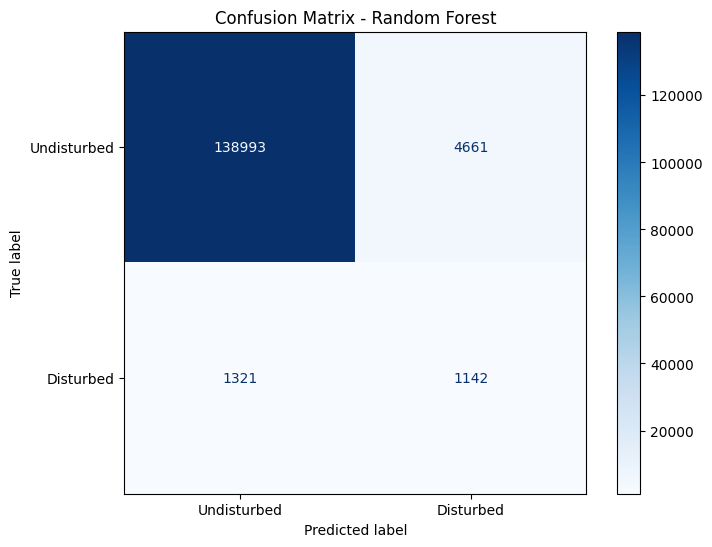


=== THRESHOLD OPTIMIZATION ===
Threshold: 0.1 | F1: 0.042 | Precision: 0.021 | Recall: 0.960
Threshold: 0.2 | F1: 0.063 | Precision: 0.033 | Recall: 0.837
Threshold: 0.3 | F1: 0.099 | Precision: 0.053 | Recall: 0.698
Threshold: 0.4 | F1: 0.168 | Precision: 0.099 | Recall: 0.567
Threshold: 0.5 | F1: 0.276 | Precision: 0.197 | Recall: 0.464
Threshold: 0.6 | F1: 0.410 | Precision: 0.431 | Recall: 0.391
Threshold: 0.7 | F1: 0.465 | Precision: 0.692 | Recall: 0.350
Threshold: 0.8 | F1: 0.470 | Precision: 0.856 | Recall: 0.324
Threshold: 0.9 | F1: 0.436 | Precision: 0.952 | Recall: 0.283

Best threshold: 0.8 with F1-score: 0.470

=== FEATURE IMPORTANCE ===
Top 10 most important features:
     feature  importance
8   NBR_diff    0.127748
12  TCW_diff    0.122159
2        NBR    0.120016
7        DIn    0.104545
6        TCW    0.076447
3       NDVI    0.072399
10  TCB_diff    0.062359
5        TCG    0.061809
1        SW2    0.054141
4        TCB    0.042050


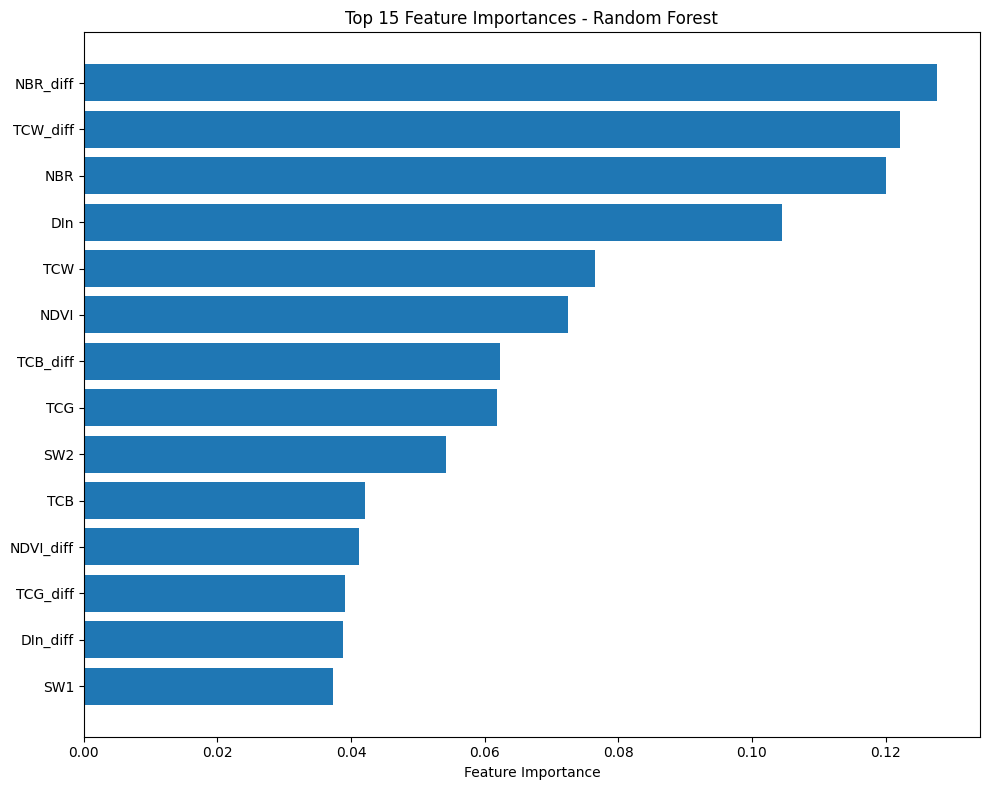


Model saved as 'best_random_forest_model.pkl'

=== MODEL SUMMARY ===
Model: Random Forest
Features: 14
Training samples: 340938
Test samples: 146117
Best test F1-score: 0.4701 (at threshold 0.8)


In [4]:
# Create Random Forest with the best hyperparameters
best_rf = RandomForestClassifier(
    n_estimators=100,
    min_samples_split=4,
    min_samples_leaf=9,
    max_features='log2',
    max_depth=15,
    class_weight='balanced',
    bootstrap=False,
    random_state=42,  # For reproducibility
    n_jobs=-1  # Use all available cores
)

# Train the model
print("Training Random Forest with best hyperparameters...")
best_rf.fit(X_train, y_train)

# Make predictions
y_train_pred = best_rf.predict(X_train)
y_test_pred = best_rf.predict(X_test)

# Get prediction probabilities for threshold tuning
y_test_proba = best_rf.predict_proba(X_test)[:, 1]  # Probabilities for class 1

# Evaluate performance
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

print("=== MODEL PERFORMANCE ===")
print(f"Training Accuracy: {accuracy_score(y_train, y_train_pred):.4f}")
print(f"Test Accuracy: {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Test Precision: {precision_score(y_test, y_test_pred):.4f}")
print(f"Test Recall: {recall_score(y_test, y_test_pred):.4f}")
print(f"Test F1-score: {f1_score(y_test, y_test_pred):.4f}")
print(f"Test ROC-AUC: {roc_auc_score(y_test, y_test_proba):.4f}")

print("\n=== DETAILED CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_test_pred, target_names=['Undisturbed (0)', 'Disturbed (1)']))

print("\n=== CONFUSION MATRIX ===")
cm = confusion_matrix(y_test, y_test_pred)
print(cm)

# Plot confusion matrix
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Undisturbed', 'Disturbed'])
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title('Confusion Matrix - Random Forest')
plt.show()

# Test different probability thresholds
print("\n=== THRESHOLD OPTIMIZATION ===")
thresholds = np.arange(0.1, 1.0, 0.1)
best_f1 = 0
best_threshold = 0.5

for threshold in thresholds:
    y_pred_thresh = (y_test_proba >= threshold).astype(int)
    f1 = f1_score(y_test, y_pred_thresh)
    precision = precision_score(y_test, y_pred_thresh)
    recall = recall_score(y_test, y_pred_thresh)
    
    print(f"Threshold: {threshold:.1f} | F1: {f1:.3f} | Precision: {precision:.3f} | Recall: {recall:.3f}")
    
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

print(f"\nBest threshold: {best_threshold:.1f} with F1-score: {best_f1:.3f}")

# Feature importance
print("\n=== FEATURE IMPORTANCE ===")
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': best_rf.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 10 most important features:")
print(feature_importance.head(10))

# Plot feature importance
plt.figure(figsize=(10, 8))
top_features = feature_importance.head(15)
plt.barh(range(len(top_features)), top_features['importance'])
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Feature Importance')
plt.title('Top 15 Feature Importances - Random Forest')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Save the model if needed
from joblib import dump
dump(best_rf, 'best_random_forest_model.pkl')
print("\nModel saved as 'best_random_forest_model.pkl'")

print("\n=== MODEL SUMMARY ===")
print(f"Model: Random Forest")
print(f"Features: {X.shape[1]}")
print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")
print(f"Best test F1-score: {best_f1:.4f} (at threshold {best_threshold:.1f})")